**Load Data**

In [142]:
import pandas as pd
import seaborn as sns

import matplotlib.pyplot as plt
%matplotlib inline

import numpy as np


In [143]:
housing_df = pd.read_csv('housing.csv')
housing_df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [144]:
housing_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


# Train the model in parallel using a Pipeline

**Preprocess Data**

In [145]:
# Verify which feature has missing values
housing_df.isnull().sum()



,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,207
population,0
households,0
median_income,0
median_house_value,0
ocean_proximity,0


In [146]:
# Calculate the precentage of missing values
MValues = housing_df['total_bedrooms'].isnull().sum()/housing_df.shape[0] * 100

print('Missing values precentage = ', MValues)

Missing values precentage =  1.002906976744186


**Impute missing data using ML -KNN**

In [147]:
from sklearn.impute import KNNImputer

# Create a temporary copy of dataset
housing_df_temp = housing_df.copy()

# Retrieve columns with numerical data (Exclude ocean_proximity column because it has categorical data)
columns_list = [col for col in housing_df_temp.columns if housing_df_temp[col].dtype != 'object']

# Extract numeric columns from the dataset from temporary dataframe
housing_numeric = housing_df_temp[columns_list]

In [148]:
# Initicalize KNN Imputer to impute missing data using ML
knn = KNNImputer(n_neighbors=3)

# Fit function to train the model
knn.fit(housing_numeric)

# Transform the data using the model & Applies the transformation model to update
array_values = knn.transform(housing_numeric)


# convert the array values into a dataframe with the appropriate column names
housing_numeric = pd.DataFrame(array_values, columns = columns_list)

# confirm there are no columns with missing values
housing_numeric.isnull().sum()



,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,0
population,0
households,0
median_income,0
median_house_value,0


In [149]:
# overlay the imputed column over the old column with missing values.
# loop through the list of columns and overlay the each one.

for column_name in columns_list:
  housing_df[column_name] = housing_numeric[column_name]

# confirm columns no longer contain null data
housing_df.isnull().sum()

,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,0
population,0
households,0
median_income,0
median_house_value,0
ocean_proximity,0


**Feature Engineering**

In [150]:
# Above scenario we already identify total_rooms, total_bedrooms, population and households are highly correlated features.
# Strategy - Create a relatively simple combination of the correlated features and drop the rest.

# 1. A new feature -> rooms_per_household.
housing_df['rooms_per_household'] = housing_df['total_rooms']/housing_df['households']

# 2. A new feature -> bedrooms_per_room.
housing_df['bedrooms_per_room'] = housing_df['total_bedrooms']/housing_df['total_rooms']

# 3. A new feature -> population_per_household.
housing_df['population_per_household'] = housing_df['population']/ housing_df['households']

# Create a new feature by combining the longitude and latitude (because there's a negative correlation)
housing_df['coords'] = housing_df['longitude']+housing_df['latitude']

housing_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   longitude                 20640 non-null  float64
 1   latitude                  20640 non-null  float64
 2   housing_median_age        20640 non-null  float64
 3   total_rooms               20640 non-null  float64
 4   total_bedrooms            20640 non-null  float64
 5   population                20640 non-null  float64
 6   households                20640 non-null  float64
 7   median_income             20640 non-null  float64
 8   median_house_value        20640 non-null  float64
 9   ocean_proximity           20640 non-null  object 
 10  rooms_per_household       20640 non-null  float64
 11  bedrooms_per_room         20640 non-null  float64
 12  population_per_household  20640 non-null  float64
 13  coords                    20640 non-null  float64
dtypes: flo

In [151]:
# After created the above new fetures, then remove the original correlated features

housing_df = housing_df.drop(['total_rooms','total_bedrooms','population','households','longitude','latitude'], axis = 1)

# Also can seperately delete each feature like -> housing_df = housing_df.drop('total_rooms', axis = 1)

housing_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 8 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   housing_median_age        20640 non-null  float64
 1   median_income             20640 non-null  float64
 2   median_house_value        20640 non-null  float64
 3   ocean_proximity           20640 non-null  object 
 4   rooms_per_household       20640 non-null  float64
 5   bedrooms_per_room         20640 non-null  float64
 6   population_per_household  20640 non-null  float64
 7   coords                    20640 non-null  float64
dtypes: float64(7), object(1)
memory usage: 1.3+ MB


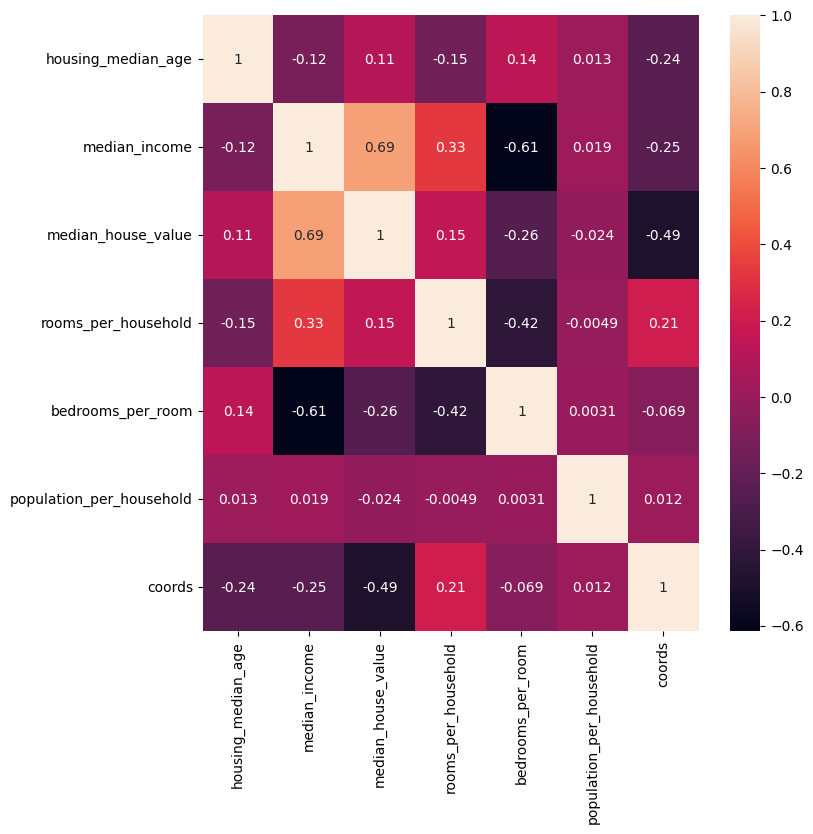

In [152]:
# New heat map after removing correlation**
corr = housing_df.corr(numeric_only=True)

#convert output with 5 decimal points
corr.round(5)

#make the heatmap larger in size
plt.figure(figsize=(8,8))

sns.heatmap(corr, annot=True)
plt.show()

**Encode Categorical Data**

In [153]:
# see unique categories for OCEAN_PROXIMITY
housing_df['ocean_proximity'].unique()

array(['NEAR BAY', '<1H OCEAN', 'INLAND', 'NEAR OCEAN', 'ISLAND'],
      dtype=object)

In [154]:
# count the values of each OCEAN_PROXIMITY category
housing_df.ocean_proximity.value_counts()

,count
ocean_proximity,
<1H OCEAN,9136
INLAND,6551
NEAR OCEAN,2658
NEAR BAY,2290
ISLAND,5


In [155]:
# One Hot Encoding

# Use panda's get_dummies() function

ocean_encoded = pd.get_dummies(housing_df['ocean_proximity'], dtype=int)
ocean_encoded

# can write this in sigle line -> print(pd.get_dummies(housing_df['ocean_proximity'])) ; output get in TRUE/False format


,<1H OCEAN,INLAND,ISLAND,NEAR BAY,NEAR OCEAN
0,0,0,0,1,0
1,0,0,0,1,0
2,0,0,0,1,0
3,0,0,0,1,0
4,0,0,0,1,0
...,...,...,...,...,...
20635,0,1,0,0,0
20636,0,1,0,0,0
20637,0,1,0,0,0
20638,0,1,0,0,0


In [156]:
# Replace 'ocean_proximity' column in the dataset using get_dummies() function
housing_df_encoded = pd.get_dummies(housing_df, columns = ['ocean_proximity'], dtype=int)


# print the first few observations
# NOTE: ocean_proximity column is gone now.

housing_df_encoded.head()

,housing_median_age,median_income,median_house_value,rooms_per_household,bedrooms_per_room,population_per_household,coords,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,41.0,8.3252,452600.0,6.984127,0.146591,2.555556,-84.35,0,0,0,1,0
1,21.0,8.3014,358500.0,6.238137,0.155797,2.109842,-84.36,0,0,0,1,0
2,52.0,7.2574,352100.0,8.288136,0.129516,2.802260,-84.39,0,0,0,1,0
3,52.0,5.6431,341300.0,5.817352,0.184458,2.547945,-84.40,0,0,0,1,0
4,52.0,3.8462,342200.0,6.281853,0.172096,2.181467,-84.40,0,0,0,1,0


**Train the model**

In [157]:
import sklearn
from sklearn.model_selection import train_test_split

# remove spaces from column names and convert all to lowercase and remove special characters as it could cause issues in the future
housing_df_encoded.columns = [c.lower().replace(' ', '_').replace('<', '_') for c in housing_df_encoded.columns]

# Split target variable and feature variables
X = housing_df_encoded[['housing_median_age', 'median_income','bedrooms_per_room','population_per_household','coords','ocean_proximity__1h_ocean',
                        'ocean_proximity_inland','ocean_proximity_island','ocean_proximity_near_bay','ocean_proximity_near_ocean']]
y = housing_df_encoded['median_house_value']

print(X)

       housing_median_age  median_income  bedrooms_per_room  \
0                    41.0         8.3252           0.146591   
1                    21.0         8.3014           0.155797   
2                    52.0         7.2574           0.129516   
3                    52.0         5.6431           0.184458   
4                    52.0         3.8462           0.172096   
...                   ...            ...                ...   
20635                25.0         1.5603           0.224625   
20636                18.0         2.5568           0.215208   
20637                17.0         1.7000           0.215173   
20638                18.0         1.8672           0.219892   
20639                16.0         2.3886           0.221185   

       population_per_household  coords  ocean_proximity__1h_ocean  \
0                      2.555556  -84.35                          0   
1                      2.109842  -84.36                          0   
2                      2.802260  

In [158]:
# import the function
# from sklearn.model_selection import train_test_split

# Define input feature (X) and target variable (y)
# X = housing_df_encoded.drop('median_house_value', axis = 1)
# y = housing_df_encoded['median_house_value']


# Split the dataset using numpy arrays
# X-> array with inputs; y-> Array with outputs

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, shuffle=True, test_size=0.3)

# Confirm how the data was split
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(14448, 10)
(6192, 10)
(14448,)
(6192,)


**ML Pipelines**

In [161]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

pipeline_lr = Pipeline([('lr_classifier', LinearRegression())])
pipeline_rf = Pipeline([('lr_classifier', RandomForestRegressor(n_estimators=100, random_state=10))])
pipeline_xgb = Pipeline([('lr_classifier', XGBRegressor())])

pipelines = [pipeline_lr, pipeline_rf, pipeline_xgb]
pipe_dict = {0: 'Linear Regression', 1: 'Random Forest Regressor', 2: 'XGBRegressor'}

for pipe in pipelines:
  pipe.fit(X_train, y_train)


for i, model in enumerate(pipelines):
  pred_test = model.predict(X_test)
  if i == 1: rf_model = model
  print("{} Test Accuracy: {}".format(pipe_dict[i], model.score(X_test, y_test)))
  print(pd.DataFrame({'Actual': y_test, 'Predicted': pred_test}))

Linear Regression Test Accuracy: 0.616322269027451
         Actual      Predicted
20046   47700.0   71338.743654
3024    45800.0  128025.243831
15663  500001.0  250721.307265
20484  218600.0  294948.751442
9814   278000.0  238462.585723
...         ...            ...
17505  237500.0  213323.706465
13512   67300.0   80877.454815
10842  218400.0  216937.315857
16559  119400.0  138647.198420
5786   209800.0  199607.771747

[6192 rows x 2 columns]
Random Forest Regressor Test Accuracy: 0.7839016354081663
         Actual  Predicted
20046   47700.0   56678.00
3024    45800.0   96564.00
15663  500001.0  459456.44
20484  218600.0  228960.00
9814   278000.0  302886.02
...         ...        ...
17505  237500.0  236974.01
13512   67300.0   66120.00
10842  218400.0  223751.00
16559  119400.0  127661.00
5786   209800.0  215282.00

[6192 rows x 2 columns]
XGBRegressor Test Accuracy: 0.7768657762851789
         Actual      Predicted
20046   47700.0   58458.757812
3024    45800.0   83409.937500
15663